# Modelo final

### Integrantes

| Nombre | Matrícula |
|---|---|
| Montserrat Gaytán Morales | A01332220 |
| Alberto Eduardo De Zamacona Garza | A00590592 |
| Ernesto Ignacio Borbón Martínez | A01701515 |

---

## Introducción

Tenco Integración de Sistemas busca **optimizar su proceso de pre-venta** en ingeniería y presupuestos,
identificando oportunidades comerciales de alto valor y reduciendo el riesgo de proyectos con baja rentabilidad.

A partir de la fase anterior seleccionamos un conjunto reducido de **9 modelos base** (los más
representativos por familia) y seguimos este flujo:

1. **Grid Search sencillo** sobre los 9 modelos base para encontrar sus mejores hiperparámetros.
2. **Validación cruzada (5 folds)** de los 9 modelos ya optimizados y comparación visual.
3. Construcción de **modelos de ensamble homogéneos** (*Bagging*), utilizando múltiples instancias de un mismo modelo y **heterogéneos** (*Voting* y *Stacking*) combinando los mejores modelos individuales como bases; su validación cruzada y una **tabla comparativa**.
4. **Selección del mejor modelo** por *score* compuesto ponderado y **análisis** de ese modelo.

Todas las métricas (*recall*, *accuracy*, *F1*, *precision*, *ROC AUC*) y el tiempo de entrenamiento se
miden bajo el mismo protocolo. El *score* compuesto prioriza el **recall (40%)**, alineado con el
objetivo de no dejar escapar oportunidades de alto valor.

## Librerías

In [ ]:
# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Manejo de datos
import pandas as pd
import numpy as np

# Validación cruzada y búsqueda de hiperparámetros
from sklearn.model_selection import cross_validate, GridSearchCV

# SHAPLEY
import shap

# Modelos de ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             precision_recall_curve, confusion_matrix)

SEED = 17  # semilla global para reproducibilidad

C:\Users\netob\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Base de datos

Cargamos la información preprocesada.

In [ ]:
# Variables predictoras (escaladas)
X_test_scaled  = pd.read_csv('X_test_scaled.csv')
X_test_scaled  = X_test_scaled[X_test_scaled.columns[1:]]
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_train_scaled = X_train_scaled[X_train_scaled.columns[1:]]

# Variable objetivo
y_test  = pd.read_csv('y_test.csv')
y_test  = y_test[y_test.columns[1:]]
y_train = pd.read_csv('y_train.csv')
y_train = y_train[y_train.columns[1:]]

# Aplanamos la y a vector 1-D (evita warnings de scikit-learn)
y_train = np.ravel(y_train)
y_test  = np.ravel(y_test)

## Modelos base

Trabajamos con **9 modelos base**, agrupados por familia. Seis son modelos individuales y tres son
ensambles homogéneos (*boosting* / *bagging*) que evaluamos en igualdad de condiciones con el resto.

* **Árbol**
  * RF gini
  * XGBoost gbtree
* **Lineal**
  * LogReg liblinear
* **No lineal**
  * SVM linear
  * SVM rbf
  * Naive Bayes
* **Ensambles homogéneos**
  * Extra Trees
  * AdaBoost
  * Hist Gradient Boosting

In [ ]:
n_vars = X_train_scaled.shape[1]

modelos = {
    # --- Árbol ---
    "RF gini":          RandomForestClassifier(criterion="gini", random_state=SEED, n_jobs=-1),
    "XGB gbtree":       xgb.XGBClassifier(booster="gbtree", eval_metric="logloss", random_state=SEED),
    # --- Lineal ---
    "LogReg liblinear": LogisticRegression(solver="liblinear", max_iter=2500, random_state=SEED),
    # --- No lineal ---
    "SVM linear":       SVC(kernel="linear", random_state=SEED),
    "SVM rbf":          SVC(kernel="rbf",    random_state=SEED),
    "Naive Bayes":      GaussianNB(),
    # --- Ensambles homogéneos ---
    "Extra Trees":      ExtraTreesClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "AdaBoost":         AdaBoostClassifier(n_estimators=300, random_state=SEED),
    "HistGradBoost":    HistGradientBoostingClassifier(random_state=SEED),
}


## Optimización de hiperparámetros (Grid Search sencillo)

Aplicamos una búsqueda en malla a cada uno de los 9 modelos base (métrica principal
**recall**, 5 folds).

In [ ]:
GRID_BASE = {
    "RF gini": {
        "n_estimators":     [200, 400],
        "max_depth":        [None, max(3, n_vars // 2)],
        "min_samples_leaf": [1, 5],
        "class_weight":     [None, "balanced"],
    },
    "XGB gbtree": {
        "n_estimators":  [200, 400],
        "max_depth":     [3, 6],
        "learning_rate": [0.1, 0.3],
    },
    "LogReg liblinear": {
        "C":       [0.1, 1, 10],
        "penalty": ["l1", "l2"],
    },
    "SVM linear": {
        "C":            [0.1, 1, 10],
        "class_weight": [None, "balanced"],
    },
    "SVM rbf": {
        "C":     [1, 10],
        "gamma": ["scale", 0.1, 0.01],
    },
    "Naive Bayes": {
        "var_smoothing": [1e-9, 1e-8, 1e-7],
    },
    "Extra Trees": {
        "n_estimators":     [200, 400],
        "max_depth":        [None, max(3, n_vars // 2)],
        "min_samples_leaf": [1, 5],
    },
    "AdaBoost": {
        "n_estimators":  [200, 400],
        "learning_rate": [0.5, 1.0],
    },
    "HistGradBoost": {
        "learning_rate":  [0.05, 0.1],
        "max_iter":       [200, 400],
        "max_leaf_nodes": [15, 31],
    },
}

In [ ]:
# Grid Search sencillo: un GridSearchCV por modelo base (scoring = recall)
resultados_grid = {}
modelos_tuned   = {}
for nombre, est in modelos.items():
    opt = GridSearchCV(estimator=clone(est), param_grid=GRID_BASE[nombre],
                       scoring="recall", cv=5, n_jobs=-1, refit=True)
    opt.fit(X_train_scaled, y_train)
    resultados_grid[nombre] = opt
    modelos_tuned[nombre]   = opt.best_estimator_     # ya viene re-entrenado (refit=True)
    n_comb = len(opt.cv_results_["params"])
    print(f"{nombre:18s} | {n_comb:3d} combinaciones | recall CV = {opt.best_score_:.4f}")

RF gini            |  16 combinaciones | recall CV = 0.9633
XGB gbtree         |   8 combinaciones | recall CV = 0.9196
LogReg liblinear   |   6 combinaciones | recall CV = 0.9323
SVM linear         |   6 combinaciones | recall CV = 0.9591
SVM rbf            |   6 combinaciones | recall CV = 0.9689
Naive Bayes        |   3 combinaciones | recall CV = 0.9450
Extra Trees        |   8 combinaciones | recall CV = 1.0000
AdaBoost           |   4 combinaciones | recall CV = 0.9153
HistGradBoost      |   8 combinaciones | recall CV = 0.8913


### Mejores hiperparámetros encontrados

In [ ]:
for nombre in modelos:
    print("=" * 60)
    print(f"{nombre}  |  recall CV = {resultados_grid[nombre].best_score_:.4f}")
    for k, v in resultados_grid[nombre].best_params_.items():
        print(f"  {k:18s}: {v}")

RF gini  |  recall CV = 0.9633
  class_weight      : None
  max_depth         : 4
  min_samples_leaf  : 5
  n_estimators      : 200
XGB gbtree  |  recall CV = 0.9196
  learning_rate     : 0.1
  max_depth         : 3
  n_estimators      : 200
LogReg liblinear  |  recall CV = 0.9323
  C                 : 0.1
  penalty           : l2
SVM linear  |  recall CV = 0.9591
  C                 : 0.1
  class_weight      : None
SVM rbf  |  recall CV = 0.9689
  C                 : 1
  gamma             : 0.01
Naive Bayes  |  recall CV = 0.9450
  var_smoothing     : 1e-09
Extra Trees  |  recall CV = 1.0000
  max_depth         : 4
  min_samples_leaf  : 1
  n_estimators      : 200
AdaBoost  |  recall CV = 0.9153
  learning_rate     : 0.5
  n_estimators      : 200
HistGradBoost  |  recall CV = 0.8913
  learning_rate     : 0.05
  max_iter          : 200
  max_leaf_nodes    : 15


## Validación cruzada de los modelos base (con sus mejores hiperparámetros)

Evaluamos los 9 modelos ya optimizados con **5-fold CV** sobre todas las métricas (`SCORING`) y el
tiempo de entrenamiento.

In [ ]:
SCORING = ['recall', 'accuracy', 'f1', 'precision', 'roc_auc']

rendimiento_clf = {}
for nombre, est in modelos_tuned.items():
    scores = cross_validate(est, X_train_scaled, y_train, cv=5, scoring=SCORING, n_jobs=-1)
    rendimiento_clf[nombre] = scores
    print(f"{nombre:18s} | ROC AUC={scores['test_roc_auc'].mean():.4f} "
          f"| recall={scores['test_recall'].mean():.4f} "
          f"| f1={scores['test_f1'].mean():.4f} "
          f"| fit={scores['fit_time'].mean():.3f}s")

RF gini            | ROC AUC=0.8680 | recall=0.9633 | f1=0.8751 | fit=0.324s
XGB gbtree         | ROC AUC=0.8955 | recall=0.9196 | f1=0.8822 | fit=0.035s
LogReg liblinear   | ROC AUC=0.8930 | recall=0.9323 | f1=0.8855 | fit=0.002s
SVM linear         | ROC AUC=0.8925 | recall=0.9591 | f1=0.8907 | fit=0.007s
SVM rbf            | ROC AUC=0.8963 | recall=0.9689 | f1=0.8905 | fit=0.009s
Naive Bayes        | ROC AUC=0.8744 | recall=0.9450 | f1=0.8587 | fit=0.002s
Extra Trees        | ROC AUC=0.8795 | recall=1.0000 | f1=0.8362 | fit=0.216s
AdaBoost           | ROC AUC=0.8888 | recall=0.9153 | f1=0.8776 | fit=0.246s
HistGradBoost      | ROC AUC=0.8964 | recall=0.8913 | f1=0.8685 | fit=0.133s


### Comparativa visual (CV) de los modelos base

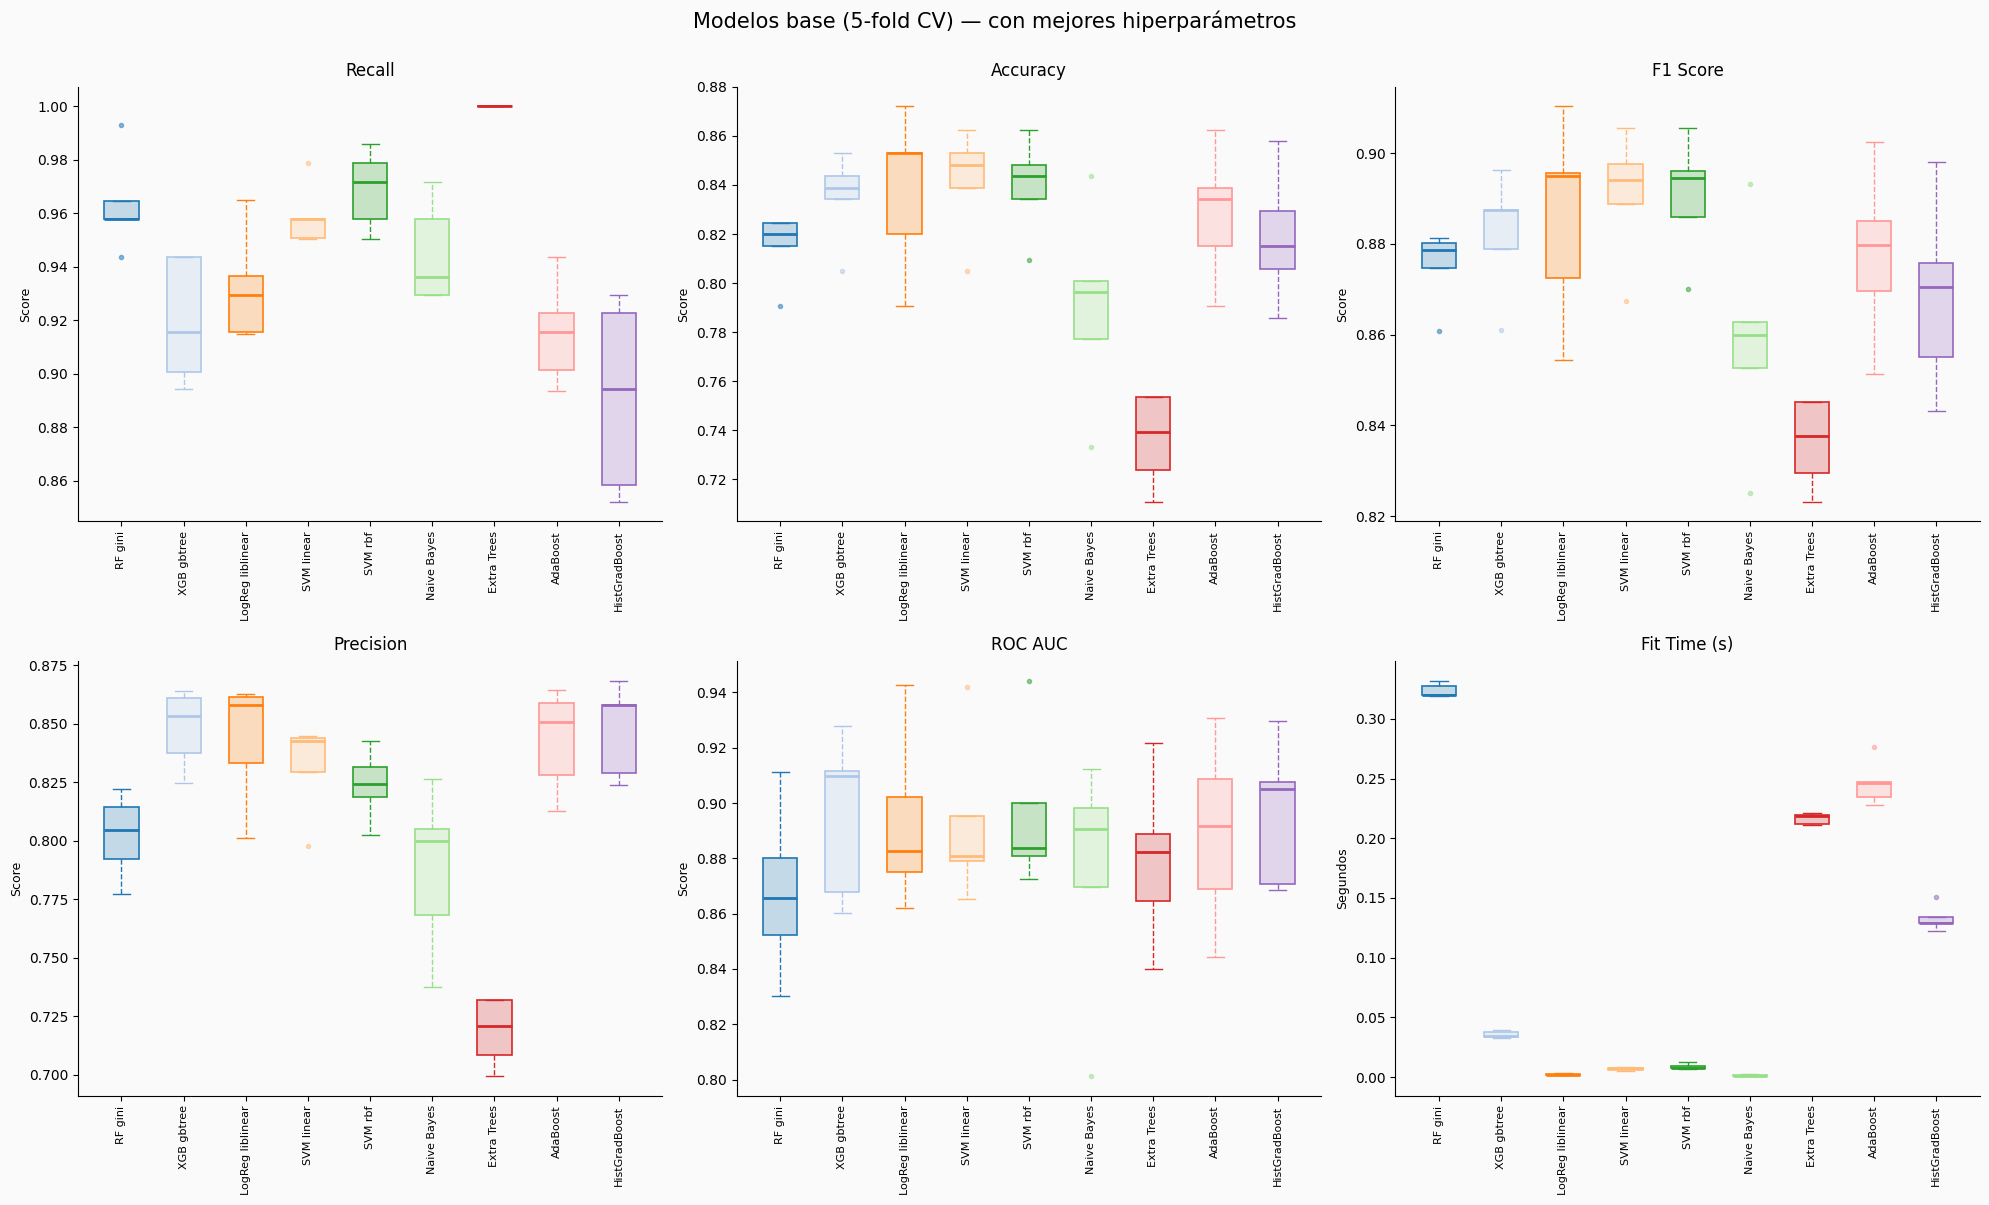

In [ ]:
METRICAS = ['test_recall', 'test_accuracy', 'test_f1', 'test_precision', 'test_roc_auc', 'fit_time']
TITULOS  = ['Recall', 'Accuracy', 'F1 Score', 'Precision', 'ROC AUC', 'Fit Time (s)']

def plot_cv(rend, titulo, archivo):
    labels = list(rend.keys())
    cmap = plt.get_cmap("tab20")
    col = {n: cmap(k % 20) for k, n in enumerate(labels)}
    fig, axs = plt.subplots(2, 3, figsize=(20, 12))
    fig.patch.set_facecolor("#FAFAFA")
    for idx, (m, t) in enumerate(zip(METRICAS, TITULOS)):
        ax = axs[idx // 3, idx % 3]
        ax.set_facecolor("#FAFAFA")
        for k, lab in enumerate(labels):
            c = col[lab]
            ax.boxplot(rend[lab][m], positions=[k], widths=0.55, patch_artist=True, manage_ticks=False,
                       boxprops=dict(facecolor=(*c[:3], 0.25), color=c, linewidth=1.2),
                       medianprops=dict(color=c, linewidth=2.0),
                       whiskerprops=dict(color=c, linewidth=1.0, linestyle="--"),
                       capprops=dict(color=c, linewidth=1.0),
                       flierprops=dict(marker="o", markerfacecolor=c, markeredgecolor=c, alpha=0.5, markersize=3))
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        ax.set_title(t, fontsize=12, fontweight="medium", pad=8)
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_ylabel("Segundos" if m == "fit_time" else "Score", fontsize=9)
    fig.suptitle(titulo, fontsize=15, fontweight="medium", y=1.0)
    plt.tight_layout()
    plt.savefig(archivo, dpi=150, bbox_inches="tight")
    plt.show()

plot_cv(rendimiento_clf, "Modelos base (5-fold CV) — con mejores hiperparámetros", "cv_modelos_base.png")

### Tabla resumen y *score* compuesto

Definimos las funciones de resumen y el score compuesto ponderado (40% recall, 20% f1 score, 20% roc_auc, 10% accuracy, 10% precision).

In [ ]:
METRICAS_SCORE = ["recall", "accuracy", "f1", "precision", "roc_auc"]

def build_summary(rend):
    rows = []
    for nombre, cv in rend.items():
        row = {"modelo": nombre}
        for m in METRICAS_SCORE:
            vals = cv[f"test_{m}"]
            row[m] = vals.mean()
            row[f"{m}_std"] = vals.std()
        row["fit_time"] = cv["fit_time"].mean()
        rows.append(row)
    return pd.DataFrame(rows)

# Pesos del score compuesto (deben sumar 1)
PESOS = {"recall": 0.40, "accuracy": 0.10, "f1": 0.20, "precision": 0.10, "roc_auc": 0.20}
assert abs(sum(PESOS.values()) - 1.0) < 1e-9, "Los pesos deben sumar 1"

resumen = build_summary(rendimiento_clf)
resumen["score"] = sum(PESOS[m] * resumen[m] for m in METRICAS_SCORE)

cols_resumen = ["modelo"] + METRICAS_SCORE + ["score", "fit_time"]
(resumen[cols_resumen]
    .sort_values("recall", ascending=False)
    .reset_index(drop=True)
    .style.format({**{m: "{:.4f}" for m in METRICAS_SCORE}, "score": "{:.4f}", "fit_time": "{:.3f}s"})
    .background_gradient(cmap="Greens", subset=METRICAS_SCORE + ["score"]))

,modelo,recall,accuracy,f1,precision,roc_auc,score,fit_time
0,Extra Trees,1.0000,0.7362,0.8362,0.7186,0.8795,0.8886,0.216s
1,SVM rbf,0.9689,0.8396,0.8905,0.8238,0.8963,0.9113,0.009s
2,RF gini,0.9633,0.8150,0.8751,0.8021,0.8680,0.8957,0.324s
3,SVM linear,0.9591,0.8415,0.8907,0.8316,0.8925,0.9076,0.007s
4,Naive Bayes,0.9450,0.7903,0.8587,0.7874,0.8744,0.8824,0.002s
5,LogReg liblinear,0.9323,0.8377,0.8855,0.8434,0.8930,0.8967,0.002s
6,XGB gbtree,0.9196,0.8349,0.8822,0.8481,0.8955,0.8917,0.035s
7,AdaBoost,0.9153,0.8282,0.8776,0.8430,0.8888,0.8866,0.246s
8,HistGradBoost,0.8913,0.8188,0.8685,0.8475,0.8964,0.8761,0.133s


# Modelos de ensamble

Con los modelos base ya optimizados construimos ensambles de ambas estrategias:

- **Bagging (SVM)** — *homogéneo*: agrega múltiples instancias del modelo SVM rbf (el mejor SVM ya optimizado).
- **Bagging (LogReg)** — *homogéneo*: agrega múltiples instancias de la regresión logística liblinear (ya optimizado).
- **Voting (soft)** — *heterogéneo*: combina los mejores modelos individuales mediante el promedio de sus probabilidades estimadas para cada clase.
- **Voting (weights)** — *heterogéneo*: variante de Voting Soft que asigna un mayor peso al modelo con mejor desempeño individual.
- **Stacking (LR)** — *heterogéneo*: un meta-modelo (Regresión Logística) que utiliza las predicciones de los mejores modelos individuales, aprendiendo cómo combinar de forma óptima las predicciones de los modelos base.

Las bases de *Voting* y *Stacking* son los **mejores modelos individuales** (no-ensamble) del paso
anterior, según el *score* compuesto.

In [ ]:
# Mejores modelos INDIVIDUALES segun score compuesto -> bases de los ensambles
ranking_base = resumen.copy()
mejores_indiv = (ranking_base.sort_values("score", ascending=False)["modelo"].tolist())

N_BASES = 3
bases_indiv = mejores_indiv[:N_BASES]
print("Mejores individuales usados como bases:", bases_indiv)

def _id(nombre):
    return (nombre.lower().replace(" ", "_").replace("(", "").replace(")", ""))

def base_voting(est):
    # Las bases del voting suave requieren predict_proba (SVM -> probability=True)
    est = clone(est)
    if isinstance(est, SVC):
        est.set_params(probability=True)
    return est

bases_voting   = [(_id(n), base_voting(modelos_tuned[n])) for n in bases_indiv]
bases_stacking = [(_id(n), clone(modelos_tuned[n]))       for n in bases_indiv]

ensambles = {
    # --- Homogeneo ---
    "Bagging (SVM)": BaggingClassifier(
        estimator=clone(modelos_tuned["SVM rbf"]).set_params(probability=True),
        n_estimators=30, n_jobs=-1, random_state=SEED),
    "Bagging (LogReg)": BaggingClassifier(
        estimator=clone(modelos_tuned["LogReg liblinear"]),
        n_estimators=30, n_jobs=-1, random_state=SEED),
    # --- Heterogeneos ---
    "Voting (soft)": VotingClassifier(estimators=bases_voting, voting="soft"),
    "Voting (weights)": VotingClassifier(estimators=bases_voting, voting="soft", weights=[2,1,1]),
    "Stacking (LR)": StackingClassifier(
        estimators=bases_stacking,
        final_estimator=LogisticRegression(max_iter=2500, random_state=SEED),
        stack_method="auto", cv=5),
}

print(f"\nEnsambles definidos: {len(ensambles)}")
for n in ensambles:
    print(" -", n)

Mejores individuales usados como bases: ['SVM rbf', 'SVM linear', 'LogReg liblinear']

Ensambles definidos: 5
 - Bagging (SVM)
 - Bagging (LogReg)
 - Voting (soft)
 - Voting (weights)
 - Stacking (LR)


### Validación cruzada de los ensambles (5-fold)

In [ ]:
rendimiento_ens = {}
for nombre, clf in ensambles.items():
    scores = cross_validate(clf, X_train_scaled, y_train, cv=5, scoring=SCORING, n_jobs=-1)
    rendimiento_ens[nombre] = scores
    print(f"{nombre:16s} | ROC AUC={scores['test_roc_auc'].mean():.4f} "
          f"| recall={scores['test_recall'].mean():.4f} "
          f"| f1={scores['test_f1'].mean():.4f} "
          f"| fit={scores['fit_time'].mean():.3f}s")

# Consolidamos: modelos base (con mejores hiperparametros) + ensambles
rendimiento_all = {**rendimiento_clf, **rendimiento_ens}
print(f"\nTotal de modelos en la comparacion: {len(rendimiento_all)}")

Bagging (SVM)    | ROC AUC=0.8962 | recall=0.9125 | f1=0.8791 | fit=0.402s
Bagging (LogReg) | ROC AUC=0.8926 | recall=0.9295 | f1=0.8834 | fit=0.073s
Voting (soft)    | ROC AUC=0.8949 | recall=0.9224 | f1=0.8826 | fit=0.086s
Voting (weights) | ROC AUC=0.8956 | recall=0.9196 | f1=0.8817 | fit=0.086s
Stacking (LR)    | ROC AUC=0.8953 | recall=0.9125 | f1=0.8791 | fit=0.136s

Total de modelos en la comparacion: 14


## Comparación de desempeño
Comparación del desempeño (CV) de los modelos base y los ensambles.

### Comparativa visual

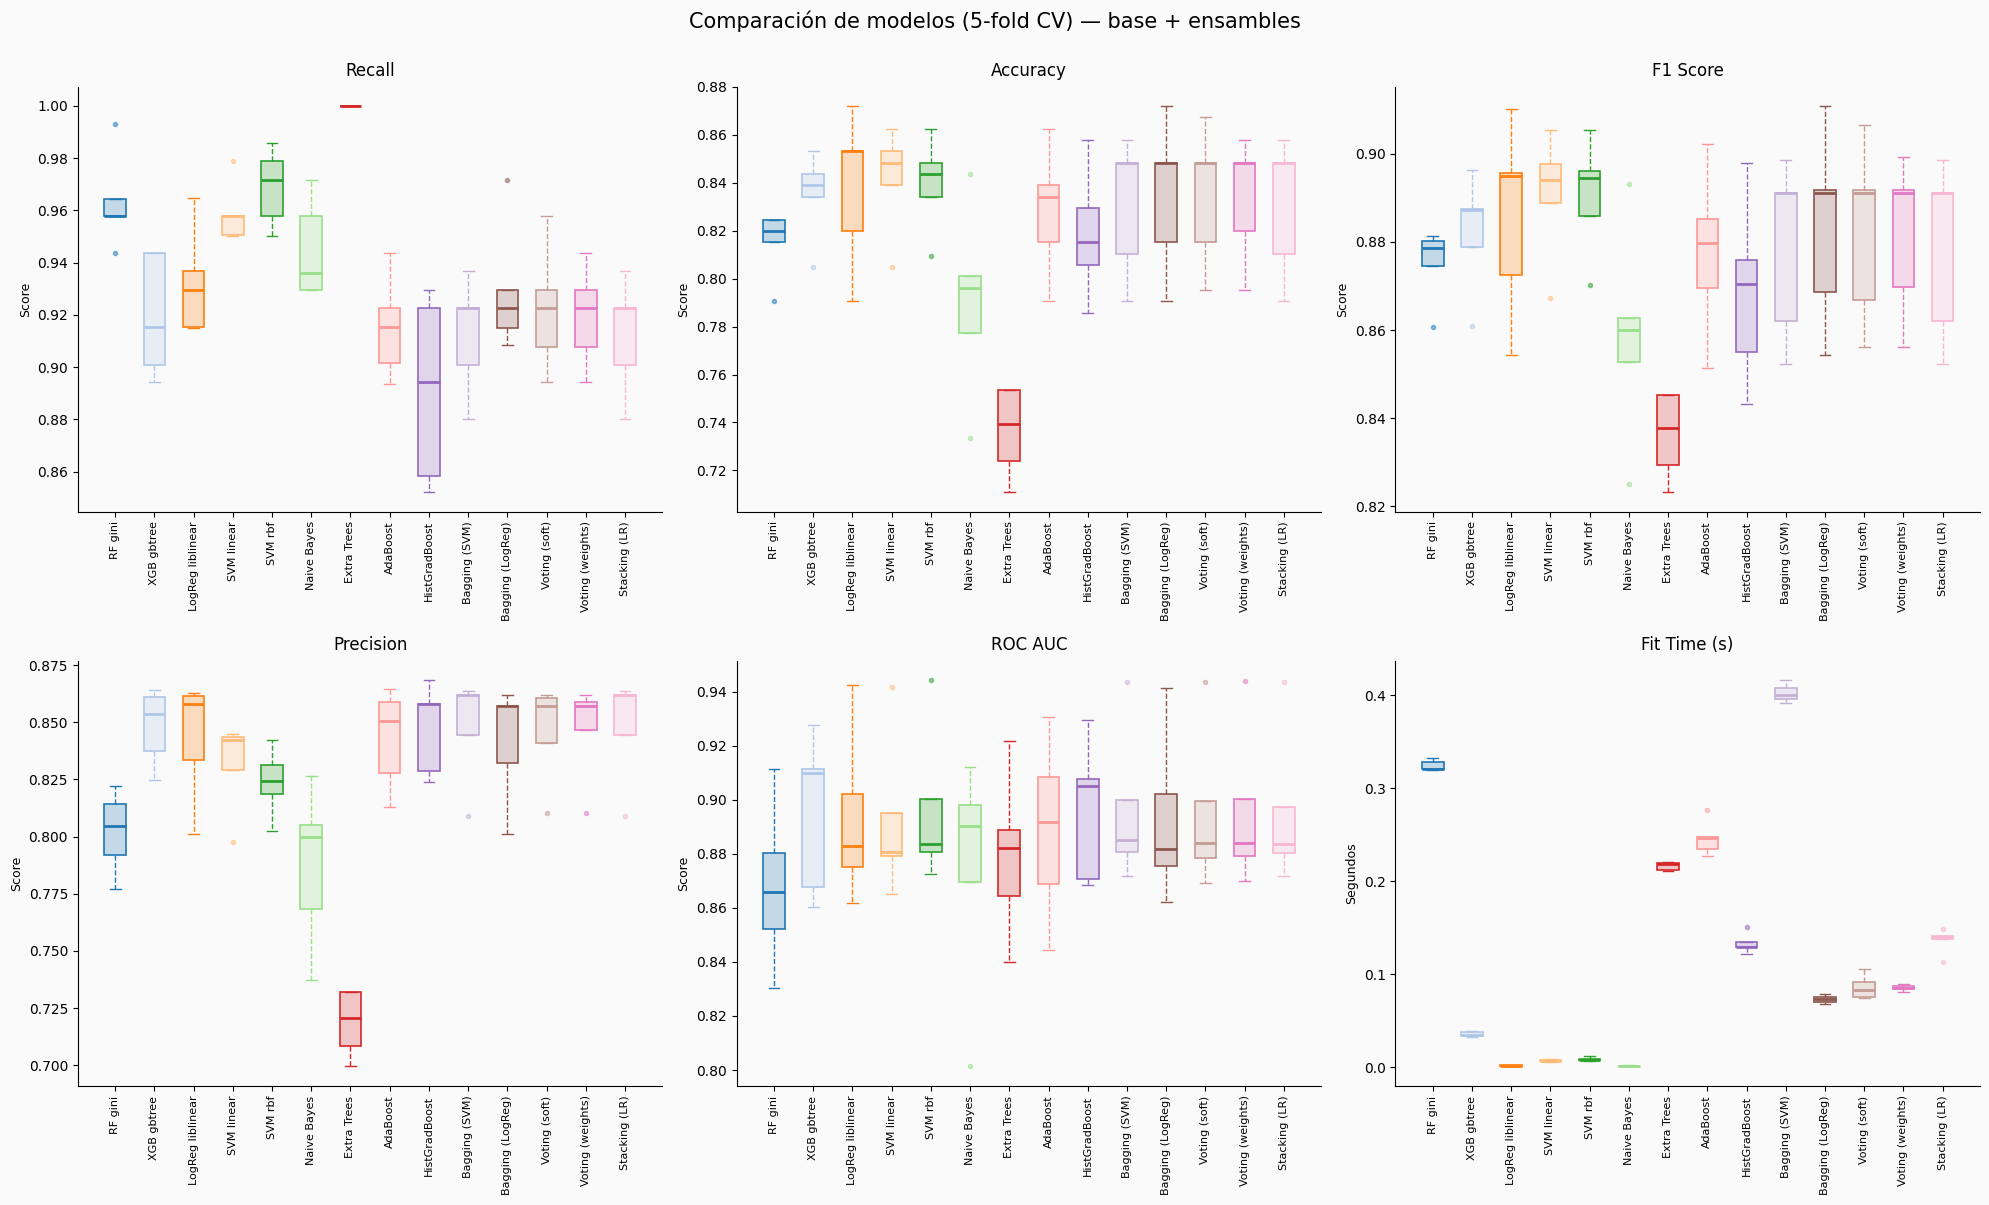

In [ ]:
plot_cv(rendimiento_all, "Comparación de modelos (5-fold CV) — base + ensambles", "comparacion_cv_todos.png")

### Tabla comparativa

In [ ]:
comparativa = build_summary(rendimiento_all)
comparativa["score"] = sum(PESOS[m] * comparativa[m] for m in METRICAS_SCORE)

cols = ["modelo"] + METRICAS_SCORE + ["score", "fit_time"]
comparativa = (comparativa[cols]
               .sort_values("recall", ascending=False)
               .reset_index(drop=True))
comparativa.index += 1
comparativa.index.name = "ranking"

(comparativa.style
    .format({**{m: "{:.4f}" for m in METRICAS_SCORE}, "score": "{:.4f}", "fit_time": "{:.3f}s"})
    .background_gradient(cmap="Greens", subset=METRICAS_SCORE + ["score"]))

,modelo,recall,accuracy,f1,precision,roc_auc,score,fit_time
ranking,,,,,,,,
1,Extra Trees,1.0000,0.7362,0.8362,0.7186,0.8795,0.8886,0.216s
2,SVM rbf,0.9689,0.8396,0.8905,0.8238,0.8963,0.9113,0.009s
3,RF gini,0.9633,0.8150,0.8751,0.8021,0.8680,0.8957,0.324s
4,SVM linear,0.9591,0.8415,0.8907,0.8316,0.8925,0.9076,0.007s
5,Naive Bayes,0.9450,0.7903,0.8587,0.7874,0.8744,0.8824,0.002s
6,LogReg liblinear,0.9323,0.8377,0.8855,0.8434,0.8930,0.8967,0.002s
7,Bagging (LogReg),0.9295,0.8349,0.8834,0.8419,0.8926,0.8947,0.073s
8,Voting (soft),0.9224,0.8349,0.8826,0.8462,0.8949,0.8926,0.086s
9,Voting (weights),0.9196,0.8339,0.8817,0.8470,0.8956,0.8914,0.086s


Como podemos observar en la tabla comparativa anterior, el modelo **SVM con kernel RBF** obtuvo el mejor desempeño global, alcanzando un score compuesto de **0.9113**, el valor más alto entre todos los modelos individuales y de ensamble evaluados. Aunque el modelo Extra Trees alcanzó el Recall máximo (1.0000), presentó una disminución importante en Accuracy (0.7362), Precision (0.7186) y F1-score (0.8362), lo que redujo su score global a 0.8886.

Al compararlo con el segundo lugar, **SVM lineal**, ambos modelos muestran un comportamiento similar. Sin embargo, SVM RBF logró un Recall superior (0.9689 frente a 0.9591), una mejor capacidad discriminante medida mediante ROC AUC (0.8963 frente a 0.8925) y el mayor score compuesto de toda la evaluación.

Respecto al tercer lugar, **Regresión Logística**, SVM RBF también presentó un mejor Recall (0.9689 frente a 0.9323), F1-score (0.8905 frente a 0.8855) y score compuesto (0.9113 frente a 0.8967), manteniendo además un desempeño competitivo en Accuracy y Precision.

Si bien los ensambles evaluados mostraron un desempeño sólido y consistente durante la validación cruzada, ninguno logró superar al modelo individual SVM RBF, que obtuvo el mejor score compuesto global.

### Comparación de las distribuciones de probabilidad de los modelos

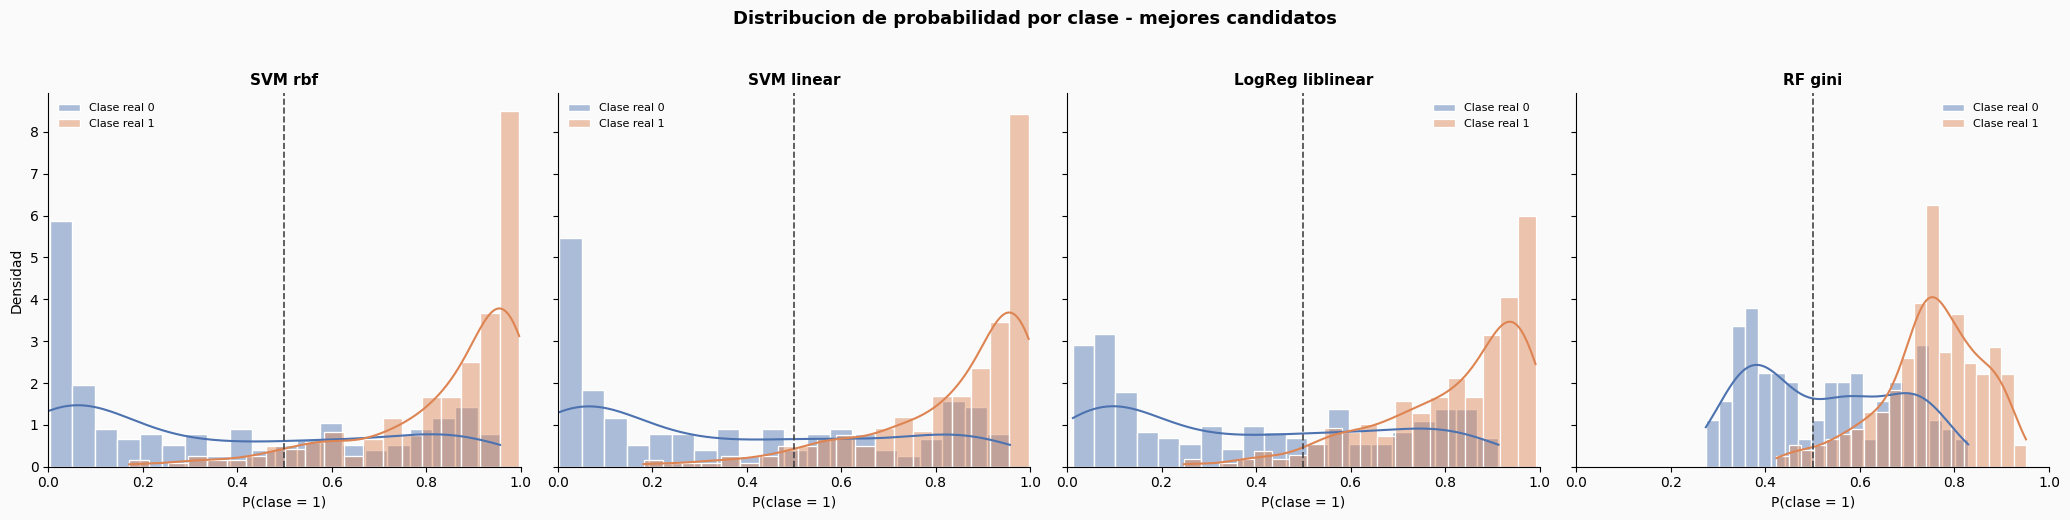

In [ ]:
# Comparamos como separan las clases los mejores candidatos del ranking (por score compuesto):
# graficamos la distribucion de P(clase = 1) segun la clase real en el conjunto de test.
_registro = {**modelos_tuned, **ensambles}

def _con_proba(est):
    est = clone(est)
    if isinstance(est, SVC):
        est.set_params(probability=True)
    if isinstance(est, VotingClassifier):
        nuevas = [(n, clone(e).set_params(probability=True)) if isinstance(e, SVC) else (n, e)
                  for n, e in est.estimators]
        est.set_params(voting="soft", estimators=nuevas)
    return est

def _p_pos(est, X):
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, list(est.classes_).index(1)]
    s = est.decision_function(X)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)   # normaliza a [0,1] para comparar

top_modelos = [m for m in comparativa.sort_values("score", ascending=False)["modelo"]
               if m in _registro][:4]

COL_CLASE = {0: "#4C72B0", 1: "#DD8452"}
fig, axes = plt.subplots(1, len(top_modelos), figsize=(5.2 * len(top_modelos), 5), sharey=True)
fig.patch.set_facecolor("#FAFAFA")
axes = np.atleast_1d(axes)
for ax, nombre in zip(axes, top_modelos):
    ax.set_facecolor("#FAFAFA")
    est = _con_proba(_registro[nombre]).fit(X_train_scaled, y_train)
    p = _p_pos(est, X_test_scaled)
    for c in (0, 1):
        sns.histplot(p[y_test == c], bins=20, stat="density", kde=True, ax=ax,
                     color=COL_CLASE[c], alpha=0.45, edgecolor="white", label=f"Clase real {c}")
    ax.axvline(0.5, ls="--", lw=1.2, color="#444444")
    ax.set_title(nombre, fontsize=11, weight="bold")
    ax.set_xlabel("P(clase = 1)")
    ax.set_xlim(0, 1)
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Densidad")
fig.suptitle("Distribucion de probabilidad por clase - mejores candidatos",
             fontsize=13, weight="bold", y=1.03)
plt.tight_layout()
plt.savefig("comparacion_distribucion_proba.png", dpi=150, bbox_inches="tight")
plt.show()

La distribución de probabilidades muestra que SVM RBF, SVM lineal y Regresión Logística presentan una separación más clara entre las clases. La mayoría de los casos de la clase negativa se concentran en probabilidades bajas, mientras que los casos positivos se ubican principalmente por encima del umbral de decisión (0.5), lo que indica una buena capacidad discriminante y una adecuada calibración de las predicciones.

Entre estos modelos, SVM RBF destaca por generar una mayor concentración de probabilidades cercanas a 0 y 1, reduciendo la incertidumbre en la clasificación y favoreciendo una mejor separación entre clases.

## Selección del modelo final
Basados en el **score compuesto** (que prioriza el recall, 40%) elegimos el mejor modelo; descartamos
cualquier candidato que prediga una sola clase o cuya probabilidad estimada sea prácticamente constante.
El modelo elegido se entrena sobre todo el *train* y se evalúa en el conjunto de **test**.

In [ ]:
from sklearn.metrics import (recall_score, accuracy_score, f1_score,
                             precision_score, roc_auc_score)

# Registro nombre -> estimador (sin entrenar) para reconstruir cada candidato
estimadores_all = {}
estimadores_all.update(modelos_tuned)   # 9 base con sus mejores hiperparametros
estimadores_all.update(ensambles)       # ensambles heterogeneos

def asegurar_proba(est):
    # Copia del estimador capaz de predict_proba (para curvas y analisis de umbral)
    est = clone(est)
    if isinstance(est, SVC):
        est.set_params(probability=True)
    if isinstance(est, VotingClassifier):
        nuevas_bases = [(n, clone(e).set_params(probability=True)) if isinstance(e, SVC) else (n, e)
                        for n, e in est.estimators]
        est.set_params(voting="soft", estimators=nuevas_bases)
    return est

def score_positivo(est, X):
    # Probabilidad de la clase positiva si existe; si no, el decision_function
    if hasattr(est, "predict_proba"):
        idx = list(est.classes_).index(1)
        return est.predict_proba(X)[:, idx]
    return est.decision_function(X)

def es_degenerado(y_pred, y_score, tol=1e-3):
    # Degenerado = predice una sola clase o su score es practicamente constante
    una_sola_clase  = len(np.unique(y_pred)) < 2
    score_constante = float(np.std(y_score)) < tol
    return una_sola_clase or score_constante

# Recorremos el ranking por score compuesto y elegimos el PRIMER modelo no degenerado.
ranking_final = comparativa.sort_values("score", ascending=False)

ganador, modelo_final, y_pred, y_score = None, None, None, None
for nombre in ranking_final["modelo"]:
    cand = asegurar_proba(estimadores_all[nombre])
    cand.fit(X_train_scaled, y_train)
    yp = cand.predict(X_test_scaled)
    ys = score_positivo(cand, X_test_scaled)
    if es_degenerado(yp, ys):
        print(f"  [descartado] {nombre}: predice una sola clase o probabilidad constante")
        continue
    ganador, modelo_final, y_pred, y_score = nombre, cand, yp, ys
    break

print(f"\n>>> Modelo final elegido: {ganador}")

desempeno_final = {
    "recall":    recall_score(y_test, y_pred),
    "accuracy":  accuracy_score(y_test, y_pred),
    "f1":        f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "roc_auc":   roc_auc_score(y_test, y_score),
}
print("\nDesempeno en TEST:")
for k, v in desempeno_final.items():
    print(f"  {k:10s}: {v:.4f}")


>>> Modelo final elegido: SVM rbf

Desempeno en TEST:
  recall    : 0.9794
  accuracy  : 0.8274
  f1        : 0.8796
  precision : 0.7983
  roc_auc   : 0.8910


Después de ser reentrenado utilizando la totalidad del conjunto de entrenamiento para su evaluación sobre el conjunto de prueba; confirmamos que **SVM RBF** ofrece el mejor equilibrio entre sensibilidad, precisión y capacidad de discriminación, alineándose adecuadamente con el objetivo del proyecto.

## Análisis del rendimiento del modelo
Mostramos las siguientes gráficas para entender cómo funciona el modelo:
matriz de confusión, curva ROC y curva Precisión-Recall.

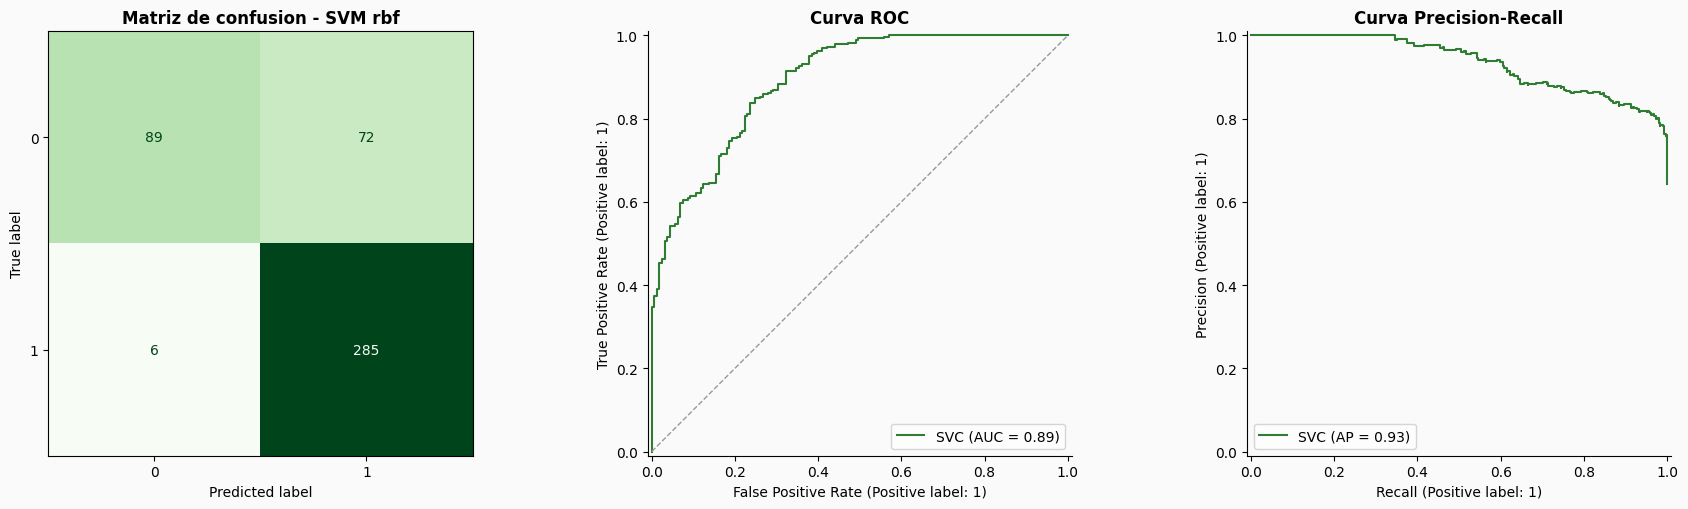

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
fig.patch.set_facecolor("#FAFAFA")

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=axes[0], cmap="Greens", colorbar=False)
axes[0].set_title(f"Matriz de confusion - {ganador}", fontsize=12, weight="bold")

# Curva ROC (usa predict_proba o decision_function automaticamente)
RocCurveDisplay.from_estimator(modelo_final, X_test_scaled, y_test, ax=axes[1], color="#2E7D32")
axes[1].plot([0, 1], [0, 1], ls="--", color="#999999", lw=1)
axes[1].set_title("Curva ROC", fontsize=12, weight="bold")

# Curva Precision-Recall
PrecisionRecallDisplay.from_estimator(modelo_final, X_test_scaled, y_test, ax=axes[2], color="#2E7D32")
axes[2].set_title("Curva Precision-Recall", fontsize=12, weight="bold")

for ax in axes[1:]:
    ax.set_facecolor("#FAFAFA")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("modelo_final_curvas.png", dpi=150, bbox_inches="tight")
plt.show()

En la **matriz de confusión**, los falsos negativos (esquina inferior izquierda)
son el error más caro para el negocio: oportunidades de alto valor que el modelo no detecta; por eso
priorizamos el recall. La **curva ROC** resume la capacidad de ordenar correctamente positivos y
negativos a lo largo de todos los umbrales (un AUC cercano a 1 indica buena separación). La **curva
Precisión-Recall** es más informativa que la ROC cuando hay desbalance de clases, ya que muestra
explícitamente el sacrificio de precisión que implica subir el recall.

### Precisión y Recall vs. umbral
Hacemos explícito el compromiso entre precisión y recall al mover el umbral de decisión.

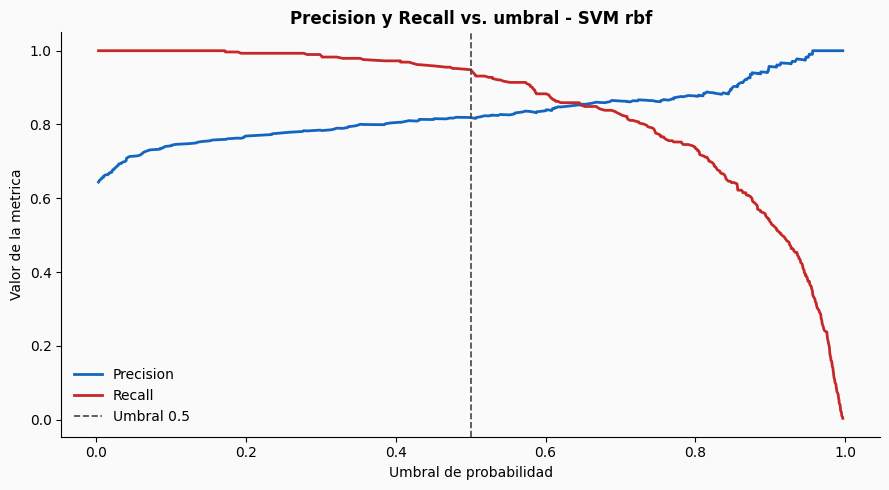

In [ ]:
prec, rec, thr = precision_recall_curve(y_test, y_score)
es_proba = (y_score.min() >= 0) and (y_score.max() <= 1)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")
ax.plot(thr, prec[:-1], label="Precision", color="#1565C0", lw=2)
ax.plot(thr, rec[:-1],  label="Recall",    color="#C62828", lw=2)
if es_proba:
    ax.axvline(0.5, ls="--", lw=1.2, color="#444444", label="Umbral 0.5")
ax.set_xlabel("Umbral de probabilidad" if es_proba else "Umbral de score (decision_function)")
ax.set_ylabel("Valor de la metrica")
ax.set_title(f"Precision y Recall vs. umbral - {ganador}", fontsize=12, weight="bold")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("modelo_final_umbral.png", dpi=150, bbox_inches="tight")
plt.show()

Este gráfico hace explícito el compromiso del negocio: bajar el umbral aumenta el
recall (captura más oportunidades reales) a costa de precisión (más falsos positivos a revisar en
pre-venta). Si el costo de perder una oportunidad supera al de revisar un prospecto de más, conviene
operar el modelo con un umbral por debajo de 0.5.

## Distribución de probabilidad por clase

Para confirmar que el modelo final sí discrimina, graficamos la distribución de `P(clase = 1)` separada
por la **clase real**.

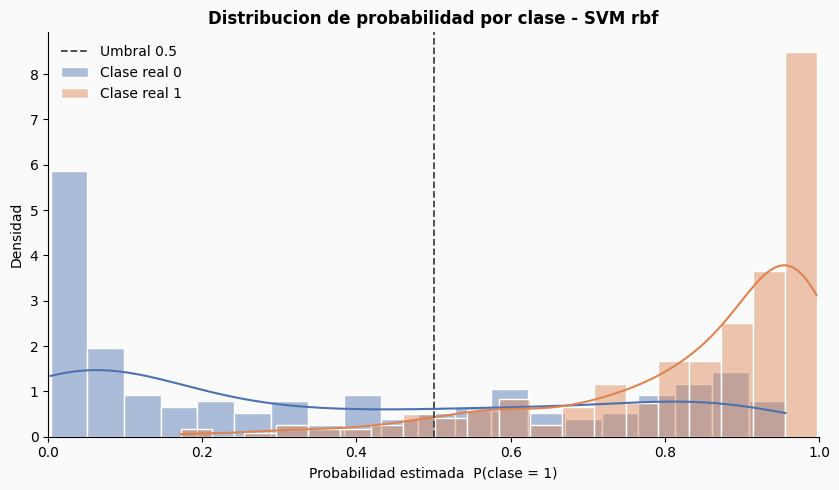

In [ ]:
COL_CLASE = {0: "#4C72B0", 1: "#DD8452"}   # azul = clase 0, naranja = clase 1
es_proba = (y_score.min() >= 0) and (y_score.max() <= 1)

fig, ax = plt.subplots(figsize=(8.5, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")
for c in (0, 1):
    sns.histplot(y_score[y_test == c], bins=20, stat="density", kde=True,
                 ax=ax, color=COL_CLASE[c], alpha=0.45, edgecolor="white",
                 label=f"Clase real {c}")
if es_proba:
    ax.axvline(0.5, ls="--", lw=1.3, color="#444444", label="Umbral 0.5")
    ax.set_xlabel("Probabilidad estimada  P(clase = 1)")
    ax.set_xlim(0, 1)
else:
    ax.set_xlabel("Score del modelo (decision_function)")
ax.set_ylabel("Densidad")
ax.set_title(f"Distribucion de probabilidad por clase - {ganador}", fontsize=12, weight="bold")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("modelo_final_distribucion_proba.png", dpi=150, bbox_inches="tight")
plt.show()

En esta gráfica podemos observar la distribución de las probabilidades estimadas por el modelo SVM RBF para cada clase real. La clase 1 está fuertemente acumulada entre 0.8 y 1.0, mientras que la clase 0 se concentra cerca de 0; es decir, que el modelo está llevando a cabo una correcta distinción entre clases. Respaldando así su selección como modelo final.

## Importancia de características

Usamos los valores shapley para poder determinar cuales son las variables más importantes.

100%|██████████| 452/452 [03:05<00:00,  2.44it/s]


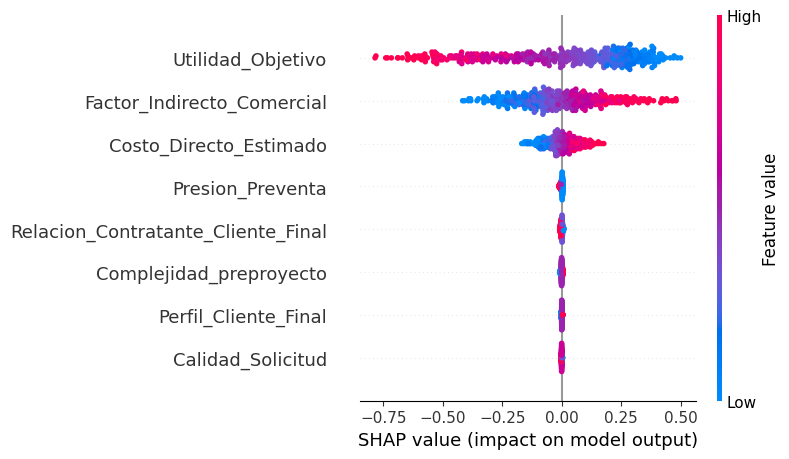

In [ ]:
# Explicar predict_proba (clase positiva) o decision_function
background = shap.kmeans(X_train_scaled, 50)
explainer = shap.KernelExplainer(modelo_final.predict_proba, background)

shap_values = explainer.shap_values(X_test_scaled)

# shap_values es una lista [clase0, clase1]; toma la clase de interés
shap.summary_plot(shap_values[..., 1], X_test_scaled)

El modelo basa la mayor parte de sus decisiones en tres variables: `Utilidad_Objetivo`, `Factor_Indirecto_Comercial` y `Costo_Directo_Estimado`. Entre ellas, la utilidad objetivo es el factor más determinante. El resto de variables aportan información limitada al proceso de clasificación, lo que sugiere que el desempeño del modelo depende principalmente de criterios económicos asociados a la rentabilidad y estructura de costos de las oportunidades evaluadas.

## Conclusión

Partiendo de 9 modelos base, se aplicó un Grid
Search sencillo para optimizar sus hiperparámetros y se evaluaron por validación cruzada (5-fold).
A partir de los mejores modelos individuales como bases se construyeron **cinco ensambles**: dos homogéneos (*Bagging SVM* y *Bagging LogReg*) y tres heterogéneo (*Voting soft*, *Voting weights* y *Stacking*); todos evaluados bajo el mismo protocolo.

La tabla comparativa reúne modelos base y ensambles, ordenados por la métrica principal (Recall), incorporando el resto de métricas (Accuracy, Precision, F1-score, ROC y AUC), el *score* compuesto y los tiempos de entrenamiento. La selección final se realizó utilizando el score compuesto, que prioriza el Recall con un peso del 40% y considera simultáneamente el desempeño global del modelo.

Bajo este criterio, **SVM RBF** el mejor resultado global, superando tanto a los demás modelos individuales como a los ensambles generados. Aunque algunos modelos alcanzaron valores más altos en métricas específicas, SVM RBF presentó el mejor equilibrio entre capacidad de detección de casos positivos, precisión y desempeño general, alineándose con el objetivo de negocio de Tenco de minimizar la pérdida de oportunidades de alto valor.

Finalmente, el modelo seleccionado fue reentrenado utilizando la totalidad del conjunto de entrenamiento y evaluado sobre el conjunto de **test**, complementando su análisis con una matriz de confusión, curvas ROC y Precisión-Recall, análisis de umbral, distribución de probabilidades e importancia de variables por permutación.

### Referencias
*   Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O´Reilly Media.